# CPE 342 - Assignment 2: Gradient Descent

| Name | Student ID |
|---|---|
| Kiatisak Markmeeshap | 67070501005 |

Fit $\hat{y} = c_0 + c_1 e^{c_2 x}$ to 100 observations by gradient descent.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

pd.set_option("display.precision", 4)

df = pd.read_csv("data/gd_data.csv")
x = df["X"].to_numpy(dtype=float)
y = df["Y"].to_numpy(dtype=float)
m = x.size

print(f"m = {m} points")
print(f"x in [{x.min():.4f}, {x.max():.4f}]")
print(f"y in [{y.min():.4f}, {y.max():.4f}]")
df.head()

m = 100 points
x in [0.0108, 4.9783]
y in [0.9493, 1.9707]


,X,Y
0,4.0723,0.9813
1,1.7243,1.1247
2,1.9020,1.0424
3,4.9141,0.9493
4,1.1659,1.1869


---
## Task 1 - Loss function

Model:

$$\hat{y}_i = c_0 + c_1 e^{c_2 x_i}$$

Residual of the $i$-th point: $r_i = \hat{y}_i - y_i$.

Loss - the mean squared error over all $m$ points:

$$\boxed{\;L(c_0, c_1, c_2)
= \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}_i - y_i\right)^2
= \frac{1}{m}\sum_{i=1}^{m}\left(c_0 + c_1 e^{c_2 x_i} - y_i\right)^2\;}$$

In [2]:
def predict(c, x):
    '''y_hat = c0 + c1 * exp(c2 * x)'''
    c0, c1, c2 = c
    return c0 + c1 * np.exp(c2 * x)


def loss(c, x, y):
    '''Mean squared error of the coefficients c on (x, y).'''
    return float(np.mean((predict(c, x) - y) ** 2))


C_INIT = np.zeros(3)
print(f"L(0, 0, 0) = {loss(C_INIT, x, y):.6f}")

L(0, 0, 0) = 1.305162


---
## Task 2 - Gradient of the loss

**Shared step.** Each coefficient reaches $L$ only through $\hat{y}_i$, so one
chain rule covers all three:

$$\frac{\partial L}{\partial c_j}
= \frac{1}{m}\sum_{i=1}^{m}\frac{\partial}{\partial c_j}\left(\hat{y}_i - y_i\right)^2
= \frac{1}{m}\sum_{i=1}^{m} 2\left(\hat{y}_i - y_i\right)\frac{\partial \hat{y}_i}{\partial c_j}
= \frac{2}{m}\sum_{i=1}^{m} r_i \frac{\partial \hat{y}_i}{\partial c_j}$$

**Three branches.** What is left is $\partial \hat{y}_i / \partial c_j$ for
$\hat{y}_i = c_0 + c_1 e^{c_2 x_i}$:

$$\frac{\partial \hat{y}_i}{\partial c_0} = 1
\qquad
\frac{\partial \hat{y}_i}{\partial c_1} = e^{c_2 x_i}
\qquad
\frac{\partial \hat{y}_i}{\partial c_2}
= c_1 \frac{\partial}{\partial c_2} e^{c_2 x_i}
= c_1 x_i e^{c_2 x_i}$$

The last one needs the chain rule a second time, on the exponent itself.

**Result.** Substituting each branch back into the shared step:

$$\boxed{\;
\begin{aligned}
\frac{\partial L}{\partial c_0} &= \frac{2}{m}\sum_{i=1}^{m} r_i \\[4pt]
\frac{\partial L}{\partial c_1} &= \frac{2}{m}\sum_{i=1}^{m} r_i e^{c_2 x_i} \\[4pt]
\frac{\partial L}{\partial c_2} &= \frac{2}{m}\sum_{i=1}^{m} r_i c_1 x_i e^{c_2 x_i}
\end{aligned}
\;}$$

where $r_i = c_0 + c_1 e^{c_2 x_i} - y_i$.

**Why this cannot be solved the way Assignment 1 was.** Setting the three partials
to zero gives a system in which $x_i$ appears both inside and outside the
exponential, so the third equation is transcendental - it has no closed-form
solution. There is no analogue of the normal equations here, which is exactly why
the coefficients have to be reached iteratively.

In [3]:
def gradient(c, x, y):
    '''[dL/dc0, dL/dc1, dL/dc2] evaluated at c.'''
    c0, c1, c2 = c
    e = np.exp(c2 * x)
    r = c0 + c1 * e - y
    return (2 / x.size) * np.array([r.sum(), (r * e).sum(), (c1 * r * x * e).sum()])


# Finite-difference check: the derivation above must match a numeric derivative.
c_test = np.array([0.8, 1.2, -1.1])
h = 1e-6
numeric = np.array([
    (loss(c_test + h * e_j, x, y) - loss(c_test - h * e_j, x, y)) / (2 * h)
    for e_j in np.eye(3)
])
analytic = gradient(c_test, x, y)

print("analytic", np.round(analytic, 8))
print("numeric ", np.round(numeric, 8))
print(f"max abs difference {np.abs(analytic - numeric).max():.2e}")
assert np.abs(analytic - numeric).max() < 1e-6

analytic [-0.25900113 -0.00712707 -0.02898728]
numeric  [-0.25900113 -0.00712707 -0.02898728]
max abs difference 5.98e-12


---
## Task 3 - Update rule

With learning rate $\eta$, one gradient descent step is

$$\mathbf{c}^{(t+1)} = \mathbf{c}^{(t)} - \eta\, \nabla L\!\left(\mathbf{c}^{(t)}\right)$$

which written out coefficient by coefficient is

$$\begin{aligned}
c_0^{(t+1)} &= c_0^{(t)} - \eta\,\frac{2}{m}\sum_{i=1}^{m} r_i \\[4pt]
c_1^{(t+1)} &= c_1^{(t)} - \eta\,\frac{2}{m}\sum_{i=1}^{m} r_i e^{c_2 x_i} \\[4pt]
c_2^{(t+1)} &= c_2^{(t)} - \eta\,\frac{2}{m}\sum_{i=1}^{m} r_i c_1 x_i e^{c_2 x_i}
\end{aligned}$$

All three residuals $r_i$ are computed from $\mathbf{c}^{(t)}$, so the whole vector
is updated at once, not one coefficient at a time.

In [4]:
ETA = 0.3
ITERATIONS = 5000

g0 = gradient(C_INIT, x, y)
print("c(0)      =", C_INIT)
print("grad L    =", np.round(g0, 6))
print("c(1)      =", np.round(C_INIT - ETA * g0, 6))

c(0)      = [0. 0. 0.]
grad L    = [-2.239027 -2.239027  0.      ]
c(1)      = [0.671708 0.671708 0.      ]


Note the third entry of the gradient: it carries a factor $c_1$, so while
$c_1 = 0$ the decay rate $c_2$ cannot move at all. The first step only lifts
$c_0$ and $c_1$ off zero; $c_2$ starts moving from the second step onwards.

---
## Task 4 - Implementation

Three routes to the same coefficients: an explicit loop that follows the formulas
literally, a vectorised version, and `scipy.optimize.curve_fit` as an independent
check.

### Method 1 - explicit loop over the points

In [5]:
import math


def gradient_descent_scalar(x, y, eta, iterations, c_init):
    '''Gradient descent written out point by point, straight from the formulas.'''
    c0, c1, c2 = c_init
    n = len(x)
    history = []
    for _ in range(iterations):
        g0 = g1 = g2 = 0.0
        squared = 0.0
        for xi, yi in zip(x, y):
            e = math.exp(c2 * xi)
            r = c0 + c1 * e - yi
            squared += r * r
            g0 += r
            g1 += r * e
            g2 += c1 * r * xi * e
        history.append(squared / n)
        c0 -= eta * 2 / n * g0
        c1 -= eta * 2 / n * g1
        c2 -= eta * 2 / n * g2
    return np.array([c0, c1, c2]), np.array(history)


c_scalar, history_scalar = gradient_descent_scalar(
    x.tolist(), y.tolist(), ETA, ITERATIONS, (0.0, 0.0, 0.0)
)
print("c =", np.round(c_scalar, 6))

c =

 [ 1.003352  0.999271 -1.529872]


### Method 2 - vectorised

In [6]:
def gradient_descent(x, y, eta, iterations, c_init):
    '''Same algorithm with numpy doing the sums. Returns coefficients and loss history.'''
    c = np.array(c_init, dtype=float)
    history = np.empty(iterations)
    for t in range(iterations):
        history[t] = loss(c, x, y)
        c = c - eta * gradient(c, x, y)
    return c, history


c_gd, history = gradient_descent(x, y, ETA, ITERATIONS, C_INIT)
print("c =", np.round(c_gd, 6))

c = [ 1.003352  0.999271 -1.529872]


### Method 3 - `scipy.optimize.curve_fit` (verification only)

In [7]:
def exp_model(x, c0, c1, c2):
    return c0 + c1 * np.exp(c2 * x)


c_ref, _ = curve_fit(exp_model, x, y, p0=[1.0, 1.0, -1.0], maxfev=20000)
print("c =", np.round(c_ref, 6))

c = [ 1.003353  0.999271 -1.529875]


### Comparison

Methods 1 and 2 are the same arithmetic in a different shape, so they agree to the
last bit. Method 3 lands a few units in the seventh decimal away: it uses a
different algorithm (Levenberg-Marquardt) with its own stopping tolerance, so the
gap measures where each one chose to stop, not a disagreement about the answer.

In [8]:
comparison = pd.DataFrame({
    "Method 1 (loop)":      [f"{v:.8f}" for v in c_scalar],
    "Method 2 (vectorised)": [f"{v:.8f}" for v in c_gd],
    "Method 3 (curve_fit)":  [f"{v:.8f}" for v in c_ref],
    "|M1 - M2|":             [f"{v:.2e}" for v in np.abs(c_scalar - c_gd)],
    "|M2 - M3|":             [f"{v:.2e}" for v in np.abs(c_gd - c_ref)],
}, index=["c0", "c1", "c2"])

assert np.abs(c_scalar - c_gd).max() < 1e-12
assert np.abs(c_gd - c_ref).max() < 1e-5
comparison

,Method 1 (loop),Method 2 (vectorised),Method 3 (curve_fit),|M1 - M2|,|M2 - M3|
c0,1.00335243,1.00335243,1.00335257,0.00e+00,1.35e-07
c1,0.99927089,0.99927089,0.99927145,0.00e+00,5.56e-07
c2,-1.52987207,-1.52987207,-1.52987496,0.00e+00,2.89e-06


---
## Task 5 - Results

### Loss over the iterations

In [9]:
checkpoints = [0, 1, 10, 100, 500, 1000, 2000, 3000, 4000, ITERATIONS - 1]
pd.DataFrame({
    "iteration": checkpoints,
    "loss (MSE)": [f"{history[k]:.8f}" for k in checkpoints],
}).set_index("iteration")

,loss (MSE)
iteration,
0,1.30516214
1,0.10198385
10,0.01498087
100,0.00464958
500,0.00092328
1000,0.00076630
2000,0.00075549
3000,0.00075541
4000,0.00075541


### Resulting coefficients and fit quality

In [10]:
c0, c1, c2 = c_gd
residual = y - predict(c_gd, x)

sse = float((residual ** 2).sum())
sst = float(((y - y.mean()) ** 2).sum())
mse = sse / m
rmse = float(np.sqrt(mse))
r_squared = 1 - sse / sst
grad_norm = float(np.linalg.norm(gradient(c_gd, x, y)))

print(f"c0   = {c0:.4f}")
print(f"c1   = {c1:.4f}")
print(f"c2   = {c2:.4f}")
print()
print(f"MSE  = {mse:.6e}")
print(f"SSE  = {sse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R^2  = {r_squared:.4f}")
print(f"||grad L|| after {ITERATIONS} iterations = {grad_norm:.2e}")

# A run that stalled somewhere else would fail here instead of printing junk.
assert grad_norm < 1e-7

print()
print(f"fitted model:  y_hat = {c0:.4f} + {c1:.4f} * exp({c2:.4f} * x)")

c0   = 1.0034
c1   = 0.9993
c2   = -1.5299

MSE  = 7.554135e-04
SSE  = 0.0755
RMSE = 0.0275
R^2  = 0.9854
||grad L|| after 5000 iterations = 2.57e-08

fitted model:  y_hat = 1.0034 + 0.9993 * exp(-1.5299 * x)


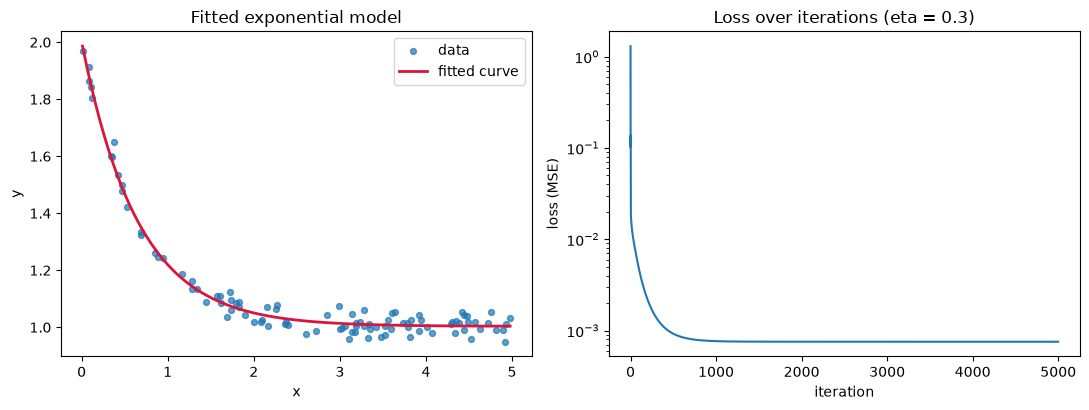

In [11]:
grid = np.linspace(x.min(), x.max(), 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(x, y, s=18, alpha=0.7, label="data")
axes[0].plot(grid, predict(c_gd, grid), color="crimson", lw=2, label="fitted curve")
axes[0].set(xlabel="x", ylabel="y", title="Fitted exponential model")
axes[0].legend()

axes[1].plot(history, lw=1.5)
axes[1].set(xlabel="iteration", ylabel="loss (MSE)", yscale="log",
            title=f"Loss over iterations (eta = {ETA})")

fig.tight_layout()
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/fit_and_loss.png", dpi=150, bbox_inches="tight")
plt.show()

**Explanation**

> _Write here._

<details><summary>Numbers you can cite</summary>

- $c_0 = 1.0034$ - the level the curve settles at; at $x = 5$ the exponential term is only 0.0005
- $c_1 = 0.9993$ - the size of the decaying part; at $x = 0$ the model predicts $c_0 + c_1 = 2.0026$
- $c_2 = -1.5299$ - the decay rate; the gap to $c_0$ halves every $\ln 2 / 1.5299 = 0.4531$ in $x$
- fit quality: MSE $= 7.554 \times 10^{-4}$, RMSE $= 0.0275$, $R^2 = 0.9854$
- the sign of $c_2$ is what makes this decay rather than growth

</details>

---
## Summary

In [12]:
pd.DataFrame([
    ["1", "loss", "MSE", f"{mse:.6e}"],
    ["2", "gradient check", "max |analytic - numeric|", f"{np.abs(analytic - numeric).max():.2e}"],
    ["3", "update rule", "learning rate / iterations", f"{ETA} / {ITERATIONS}"],
    ["4", "coefficients", "c0, c1, c2", f"{c0:.4f}, {c1:.4f}, {c2:.4f}"],
    ["5", "fit", "SSE / RMSE / R^2", f"{sse:.4f} / {rmse:.4f} / {r_squared:.4f}"],
    ["5", "convergence", "||grad L|| at the end", f"{grad_norm:.2e}"],
], columns=["Task", "Quantity", "Measure", "Value"])

,Task,Quantity,Measure,Value
0,1,loss,MSE,7.554135e-04
1,2,gradient check,max |analytic - numeric|,5.98e-12
2,3,update rule,learning rate / iterations,0.3 / 5000
3,4,coefficients,"c0, c1, c2","1.0034, 0.9993, -1.5299"
4,5,fit,SSE / RMSE / R^2,0.0755 / 0.0275 / 0.9854
5,5,convergence,||grad L|| at the end,2.57e-08


### Closed form versus gradient descent

| | Assignment 1 - OLS line | Assignment 2 - exponential model |
|---|---|---|
| Model | $\hat{y} = \beta_0 + \beta_1 x$ | $\hat{y} = c_0 + c_1 e^{c_2 x}$ |
| Closed form | yes - the normal equations | no - $\partial L / \partial c_2 = 0$ is transcendental |
| Learning rate | not needed | required, and the run fails if it is too large |
| Starting values | not needed | required; a poor start can reach a different answer |
| Global minimum | guaranteed - the loss is convex | not guaranteed - only a stationary point is reached |
| Cost | one matrix solve | thousands of passes over the data |

The check that closes the gap: `curve_fit` reaches the same coefficients from a
different algorithm, and the gradient norm printed above is of order 1e-8 at the
point gradient descent stopped, so the run did settle at a genuine minimum.